# Feature Engineering

**Project:** R2 - Bike Sharing Demand

**Team:** Angelina Bautista & Molly Scally




## Table of Contents
1. Load preprocessed data
2. Create new features (ratios, bins, interactions, log transformation)
3. Encode categorical features
4. Scale numerical features
5. Feature selection
6. Save final data for modeling

In [1]:
## import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load and quick prep

In [ ]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')

print(f'X_train shape: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns')
print(f'y_train shape: {y_train.shape[0]:,} rows x {y_train.shape[1]} columns')

print(f'X_test shape: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns')
print(f'y_test shape: {y_test.shape[0]:,} rows x {y_test.shape[1]} columns')

print('\npreview of X_train:')
display(X_train.head())

X_train shape: 13,903 rows x 61 columns
y_train shape: 13,903 rows x 1 columns
X_test shape: 3,476 rows x 61 columns
y_test shape: 3,476 rows x 1 columns

preview of X_train:


,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_0,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,0.60,0.6212,0.46,0.4179,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
1,0.60,0.5606,0.83,0.1045,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False
2,0.44,0.4394,0.94,0.0000,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False
3,0.30,0.3182,0.49,0.0000,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False
4,0.12,0.1212,0.50,0.2239,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False


Below we have a summary of the columns and datatypes in X_train: 

In [11]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13903 entries, 0 to 13902
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temp          13903 non-null  float64
 1   atemp         13903 non-null  float64
 2   hum           13903 non-null  float64
 3   windspeed     13903 non-null  float64
 4   season_1      13903 non-null  bool   
 5   season_2      13903 non-null  bool   
 6   season_3      13903 non-null  bool   
 7   season_4      13903 non-null  bool   
 8   yr_0          13903 non-null  bool   
 9   yr_1          13903 non-null  bool   
 10  mnth_1        13903 non-null  bool   
 11  mnth_2        13903 non-null  bool   
 12  mnth_3        13903 non-null  bool   
 13  mnth_4        13903 non-null  bool   
 14  mnth_5        13903 non-null  bool   
 15  mnth_6        13903 non-null  bool   
 16  mnth_7        13903 non-null  bool   
 17  mnth_8        13903 non-null  bool   
 18  mnth_9        13903 non-nu

Looks like the preprocessed data has been loaded correctly.   

There are 13,903 rows and 61 columns.   

The categorical columns were converted into dummies in the last notebook. 

The numerical features are all float, while the dummies appear to be boolean, which we will eventually convert to integer (1/0) format. Let's list each type now: 

In [3]:
## check column types

numerical_cols = X_train.select_dtypes(include=['float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='bool').columns.tolist()

print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')
print(f'Categorical ({len(categorical_cols)}): {categorical_cols}')

Numerical (4): ['temp', 'atemp', 'hum', 'windspeed']
Categorical (57): ['season_1', 'season_2', 'season_3', 'season_4', 'yr_0', 'yr_1', 'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_0', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_0', 'holiday_1', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'workingday_0', 'workingday_1', 'weathersit_1', 'weathersit_2', 'weathersit_3', 'weathersit_4']


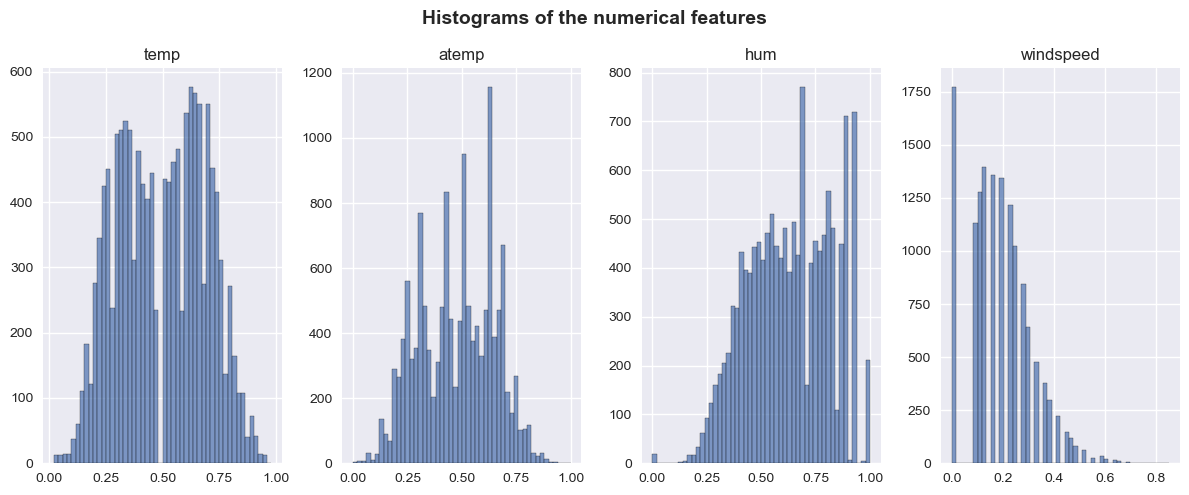

In [21]:
# histograms for numerical features
f, ax = plt.subplots(1, 4, figsize=(12, 5))
ax = ax.flatten()

for i, col in enumerate(numerical_cols):
    ax[i].hist( X_train[col], bins=50, edgecolor='black', alpha=0.7 )
    ax[i].set_title(col)
    ax[i].set_xlabel('')

plt.suptitle('Histograms of the numerical features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations 

Data shapes:   
- `X_train` shape: 13,903 rows x 61 columns  
- `X_test` shape: 3,476 rows x 61 columns  

Feature count by data type: 
- 4 numerical features  
- 57 categorical features (that is, after creating dummies early, in the last notebook). Originally, there were 8 categorical features. These all appear to be `bool` datatype and will need to be converted to 1/0 in this notebook. 

Columns to engineer features on:  
- `hr_1-hr_23`: can bin these into broader time-of-day categories i.e. dawn/day/evening etc  
- interaction features (feature * feature) between the above and `workingday`  
- as `atemp` takes humidity into account, we could subtract the corresponding `temp` from it to capture this humidity effect  
- interaction term between `temp` and `windspeed`, `hum` and `windspeed`, and/or `atemp` and `windspeed`  

## 2. Create new features

### `is_dawn`, `is_morning`, `is_afternoon`, `is_evening`  

We categorize `hr_1-hr_23` into dawn, morning, afternoon, evening by appying the following scheme:   
- Dawn = 05:00 - 07:00   
- Morning = 08:00 - 11:00   
- Afternoon = 12:00 - 16:00   
- Evening = 17:00 - 19:00 (5:00-7:00PM)  
- Night = 20:00 - 23:00 and 00:00 to 04:00, but is not created to avoid redundancy ("Night" can be interpreted as any time when all 'is_dawn', 'is_morning', 'is_afternoon', and 'is_evening' are 0)  

In [4]:
# dawn: 5-7
X_train["is_dawn"] = X_train[[f"hr_{i}" for i in range(5, 8)]].any(axis=1).astype(int)
X_test["is_dawn"] = X_test[[f"hr_{i}" for i in range(5, 8)]].any(axis=1).astype(int)

# morning: 8-11
X_train["is_morning"] = X_train[[f"hr_{i}" for i in range(8, 12)]].any(axis=1).astype(int)
X_test["is_morning"] = X_test[[f"hr_{i}" for i in range(8, 12)]].any(axis=1).astype(int)

# afternoon: 12-16
X_train["is_afternoon"] = X_train[[f"hr_{i}" for i in range(12, 17)]].any(axis=1).astype(int)
X_test["is_afternoon"] = X_test[[f"hr_{i}" for i in range(12, 17)]].any(axis=1).astype(int)

# evening: 17-19
X_train["is_evening"] = X_train[[f"hr_{i}" for i in range(17, 20)]].any(axis=1).astype(int)
X_test["is_evening"] = X_test[[f"hr_{i}" for i in range(17, 20)]].any(axis=1).astype(int)

# night: remaining hours of 20-23 + 0-4; redundant 

### `rush_hour`

This would aim to capture elevated bike demand during the 5-7 PM time on working days only. 

Defined as `is_evening` x `workingday_1`: 

In [5]:
X_train["rush_hour"] = X_train["is_evening"] * X_train["workingday_1"]
X_test["rush_hour"] = X_test["is_evening"] * X_test["workingday_1"]

### `temp_extreme`, `atemp_extreme`, `hum_extreme`, `windspeed_extreme`

Flags for extremes in the range of each environmental feature.  

Each of these becomes "1" for any point at which it either falls below the 10th percentile or exceeds the 90th percentile of its underlying numerical feature's range.  

In [6]:
for col in ["temp", "atemp", "hum", "windspeed"]:
    low_thresh = X_train[col].quantile(0.1)
    high_thresh = X_train[col].quantile(0.9)

    X_train[f"{col}_extreme"] = (
        (X_train[col] <= low_thresh) | (X_train[col] >= high_thresh)
    ).astype(int)

    X_test[f"{col}_extreme"] = (
        (X_test[col] <= low_thresh) | (X_train[col] >= high_thresh)
    ).astype(int)

### `temp_diff` 

This feature aims to capture the effect of humidity, i.e. the relative difference between simply the `temp` and `atemp` (which, as the ncorporates humidity to form the "feels like")

In [7]:
X_train['temp_diff'] = X_train['atemp'] - X_train['temp']
X_test['temp_diff'] = X_test['atemp'] - X_test['temp']

### `temp_windspeed`

This feature is the interaction between `temp` and `windspeed`. The aim of including this would be to capture any additional effect on rental count that could be present at particular windspeeds.  

In [8]:
X_train["temp_windspeed"] = X_train["temp"] * X_train["windspeed"]
X_test["temp_windspeed"] = X_test["temp"] * X_test["windspeed"]

### `hum_windspeed`

Similar to above

In [9]:
X_train["hum_windspeed"] = X_train["hum"] * X_train["windspeed"]
X_test["hum_windspeed"] = X_test["hum"] * X_test["windspeed"]

In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13903 entries, 0 to 13902
Data columns (total 73 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temp               13903 non-null  float64
 1   atemp              13903 non-null  float64
 2   hum                13903 non-null  float64
 3   windspeed          13903 non-null  float64
 4   season_1           13903 non-null  bool   
 5   season_2           13903 non-null  bool   
 6   season_3           13903 non-null  bool   
 7   season_4           13903 non-null  bool   
 8   yr_0               13903 non-null  bool   
 9   yr_1               13903 non-null  bool   
 10  mnth_1             13903 non-null  bool   
 11  mnth_2             13903 non-null  bool   
 12  mnth_3             13903 non-null  bool   
 13  mnth_4             13903 non-null  bool   
 14  mnth_5             13903 non-null  bool   
 15  mnth_6             13903 non-null  bool   
 16  mnth_7             139

## 3. Encode categorical columns

After creating new features in the last stage, let's get counts of each datatype (bool vs integer): 

In [10]:
# check datatypes of categorical columns
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
int_cols = X_train.select_dtypes(include=['int64']).columns.tolist()


print(f'boolean ({len(bool_cols)}): {bool_cols}')
print(f'integer ({len(int_cols)}): {int_cols}')

boolean (57): ['season_1', 'season_2', 'season_3', 'season_4', 'yr_0', 'yr_1', 'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_0', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_0', 'holiday_1', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'workingday_0', 'workingday_1', 'weathersit_1', 'weathersit_2', 'weathersit_3', 'weathersit_4']
integer (9): ['is_dawn', 'is_morning', 'is_afternoon', 'is_evening', 'rush_hour', 'temp_extreme', 'atemp_extreme', 'hum_extreme', 'windspeed_extreme']


Now, the boolean columns are transformed from True/False to 1/0: 

In [11]:
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

Now, we recheck. We should observe that all 66 categorical features are now integer, with zero boolean. 

In [12]:
# recheck categorical column data types
bool_cols = X_train.select_dtypes(include=['bool']).columns.tolist()
int_cols = X_train.select_dtypes(include=['int64']).columns.tolist()

print(f'boolean ({len(bool_cols)}): {bool_cols}')
print(f'integer ({len(int_cols)}): {int_cols}')

boolean (0): []
integer (66): ['season_1', 'season_2', 'season_3', 'season_4', 'yr_0', 'yr_1', 'mnth_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'hr_0', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21', 'hr_22', 'hr_23', 'holiday_0', 'holiday_1', 'weekday_0', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'workingday_0', 'workingday_1', 'weathersit_1', 'weathersit_2', 'weathersit_3', 'weathersit_4', 'is_dawn', 'is_morning', 'is_afternoon', 'is_evening', 'rush_hour', 'temp_extreme', 'atemp_extreme', 'hum_extreme', 'windspeed_extreme']


Finally, let's store this column list (int_cols) under a new name `categorical_cols` for clarity in the following steps: 

In [13]:
categorical_cols = int_cols

## 4. Scale numerical features

First let's get an updated list of the numerical features list after we created the new features. 

In [14]:
numerical_cols = X_train.select_dtypes(include=['float64']).columns.tolist()
print(f'Numerical ({len(numerical_cols)}): {numerical_cols}')

Numerical (7): ['temp', 'atemp', 'hum', 'windspeed', 'temp_diff', 'temp_windspeed', 'hum_windspeed']


Let's take a look at the ranges of these features: 

In [15]:
# Check ranges before scaling
print("Feature ranges BEFORE scaling:")
print(X_train[numerical_cols].describe().loc[['min', 'max']].round(2))

Feature ranges BEFORE scaling:
     temp  atemp  hum  windspeed  temp_diff  temp_windspeed  hum_windspeed
min  0.02    0.0  0.0       0.00      -0.62            0.00           0.00
max  0.98    1.0  1.0       0.85       0.09            0.68           0.57


One thing to note is that the original numerical features `temp`, `atemp`, `hum`, and `windspeed` are actually already very similar in scale. 

In [16]:
# get subsets of the categorical columns (which we leave out of the scaling procedure)
X_train_categorical = X_train[categorical_cols]
X_test_categorical = X_test[categorical_cols]

#### apply scaling
from sklearn.preprocessing import StandardScaler  
scaler = StandardScaler()

X_train_standard = scaler.fit_transform(X_train[numerical_cols])
X_test_standard = scaler.transform(X_test[numerical_cols])

X_train_standard = pd.DataFrame(X_train_standard, columns=numerical_cols, index=X_train.index)
X_test_standard = pd.DataFrame(X_test_standard, columns=numerical_cols, index=X_test.index)

# Reattach the unscaled binary dummies
X_train_standard[categorical_cols] = X_train[categorical_cols]
X_test_standard[categorical_cols]  = X_test[categorical_cols]

print('Scaling complete')
print(f'\n Sample mean (should be ~0 for train):')
print(X_train_standard.mean().round(4).head())
print(f'\n Sample stds (should be ~1 for train):')
print(X_test_standard.std().round(4).head())

Scaling complete

 Sample mean (should be ~0 for train):
temp         0.0
atemp       -0.0
hum         -0.0
windspeed   -0.0
temp_diff    0.0
dtype: float64

 Sample stds (should be ~1 for train):
temp         0.9991
atemp        1.0006
hum          1.0071
windspeed    1.0155
temp_diff    1.1094
dtype: float64


We can also confirm visually the change in scaling via each variable's histogram: 

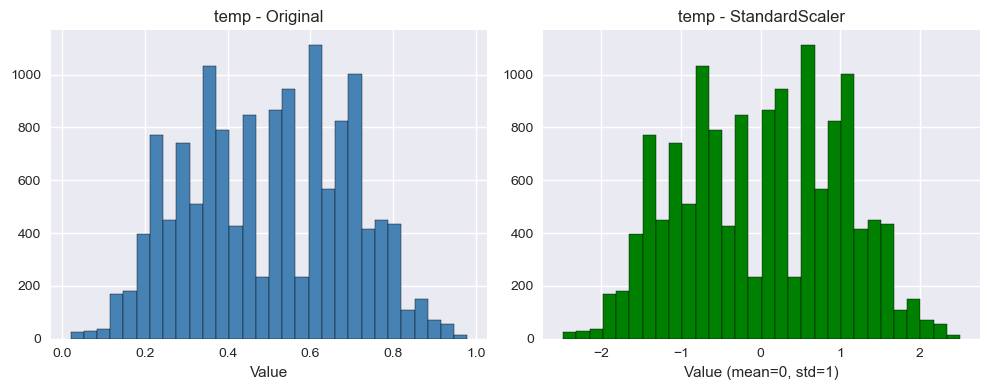

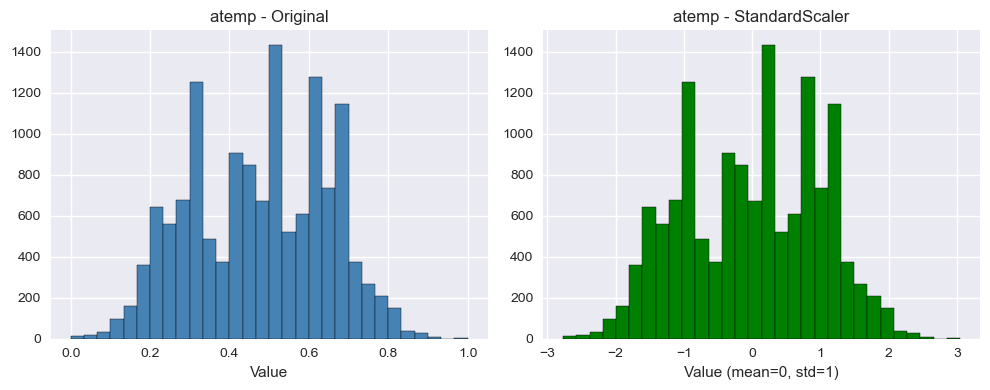

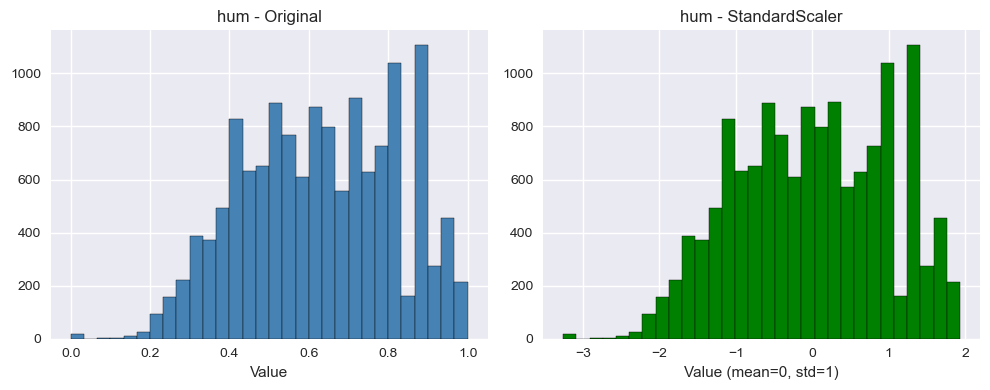

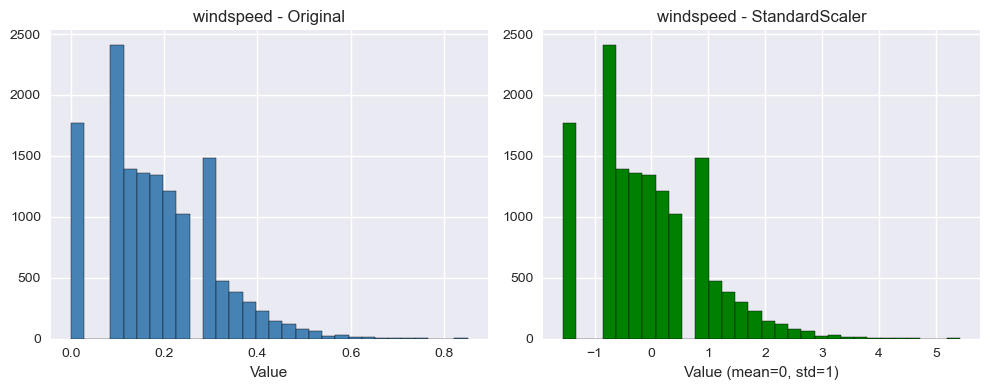

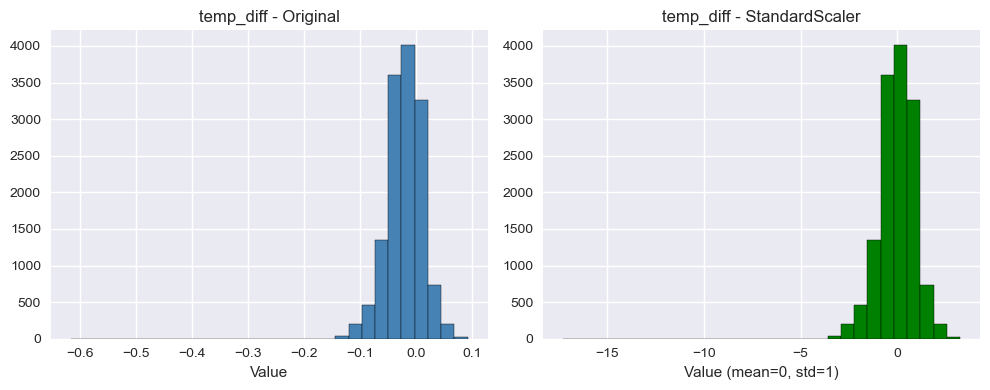

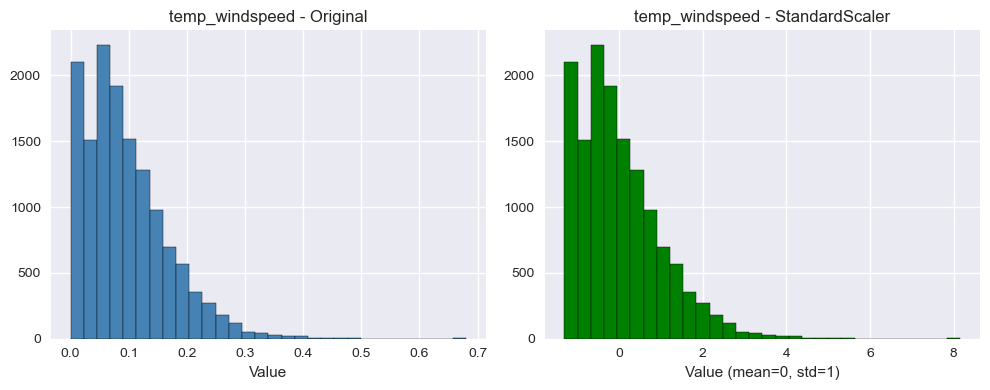

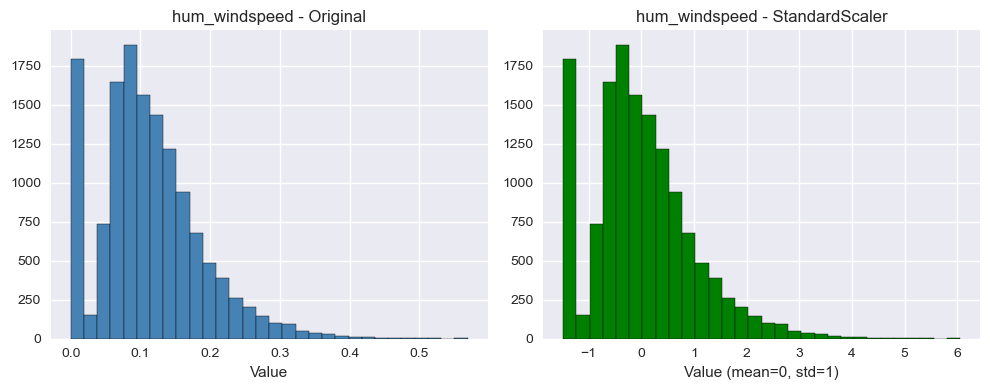

In [17]:
# Compare before/after for each numerical variable
for feature in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(X_train[feature], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_title(f'{feature} - Original')
    axes[0].set_xlabel('Value')

    axes[1].hist(X_train_standard[feature], bins=30, color='green', edgecolor='black')
    axes[1].set_title(f'{feature} - StandardScaler')
    axes[1].set_xlabel('Value (mean=0, std=1)')

    plt.tight_layout()
    plt.show()

## 5. Feature selection

Now we will investigate the quality of the feature set.  

Correlation analysis will follow, allowing us to look for: 
- unehelpful features (which would display low correlation with the target (`cnt`))
- redundant features (which would show up as being highly correlated with other features, pointing to multicollinearity)

First we simply calculate the Pearson correlation coefficient between each feature and `cnt`, and look at the top and bottom 10 (as opposed to the full list, as there are 73 features). Those with the highest correlation to `cnt` are displayed at the top and are listed in descending order from there. 

In [22]:
correlation_matrix = pd.concat([X_train_standard, y_train],axis=1).corr()

correlations = correlation_matrix['cnt'].abs().sort_values(ascending=False)
correlations = correlations.drop('cnt')

print('Top 10 features correlated with target:')
print(correlations.head(10).round(4))

print(f'\nBottom 10:')
print(correlations.tail(10).round(4))

Top 10 features correlated with target:
rush_hour         0.4513
is_evening        0.4386
temp              0.4021
atemp             0.3990
hum               0.3225
hr_17             0.3185
temp_windspeed    0.3021
hr_18             0.2683
temp_diff         0.2578
yr_0              0.2484
Name: cnt, dtype: float64

Bottom 10:
hr_10            0.0164
weekday_5        0.0160
weekday_1        0.0093
weekday_3        0.0066
weathersit_4     0.0059
weekday_6        0.0047
mnth_4           0.0036
atemp_extreme    0.0033
hum_extreme      0.0025
weekday_2        0.0009
Name: cnt, dtype: float64


It seems that the most predictive features according to correlation are `rush_hour` (r=0.4513), `is_evening` (r=0.4386), `temp` (r=0.4021), `atemp` (r=0.3990), `hum` (r=0.3225), `hr_17` (r=0.3185), and so on from there.   
Least correlated are `weekday_2` (r=0.0009), `hum_extreme` (0.0025), `atemp_extreme` (r=0.0033), and up from there.  

It would be unsurprising if several of the high-correlation-to-target features turn out to have high correlattions amongst themselves. For example, `rush_hour`, `is_evening`, and `hr_17`, as `hr_17` was used to form `is_evening`, and `is_evening` was used to create `rush_hour`. Also, `temp` and `atemp` track together, and `atemp` is formulated to take `hum` into account, so we should eventually choose to use either `temp` and `hum` OR `atemp`, but not all three. 

Here are those top features again, visualized: 

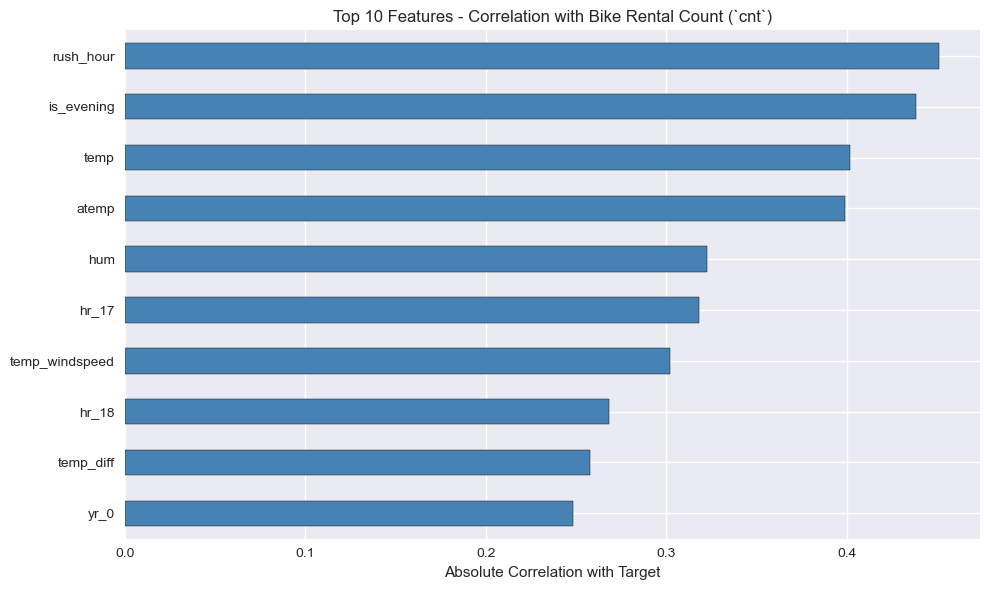

In [23]:
## visualize top 10 feature correlations with target
top10 = correlations.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh', color='steelblue',edgecolor='black')
plt.xlabel('Absolute Correlation with Target')
plt.title('Top 10 Features - Correlation with Bike Rental Count (`cnt`)')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [52]:
# find pairs with absolute correlation > 0.8
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range (i+1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.8:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)

print("Highly correlated feature pairs (>0.8):")
high_corr_df.sort_values(by='Feature 1')


Highly correlated feature pairs (>0.8):


,Feature 1,Feature 2,Correlation
7,holiday_0,holiday_1,-1.000000
2,is_evening,rush_hour,0.809634
0,temp,atemp,0.988539
3,temp_extreme,atemp_extreme,0.807432
4,weathersit_1,weathersit_2,-0.821835
1,windspeed,hum_windspeed,0.816640
6,workingday_0,workingday_1,-1.000000
5,yr_0,yr_1,-1.000000


In [ ]:
# X_train.drop(columns=['holiday_0', 'workingday_0', 'yr_0'])
# X_test.drop(columns=['holiday_0', 'workingday_0', 'yr_0'])

## 6. Save final data for modeling

In [ ]:
import os

os.makedirs('../data/modeling', exist_ok=True)

# Save unscaled (for tree models)
X_train.to_csv('../data/modeling/X_train.csv', index=False)
X_test.to_csv('../data/modeling/X_test.csv', index=False)
y_train.to_csv('../data/modeling/y_train.csv', index=False)
y_test.to_csv('../data/modeling/y_test.csv', index=False)

# Save scaled (for linear models)
X_train_standard.to_csv('../data/modeling/X_train_standard.csv', index=False)
X_test_standard.to_csv('../data/modeling/x_test_standard.csv', index=False)


print("Data saved!")
print(f"  train_engineered.csv: {X_train.shape[1]} columns (unscaled)")
print(f"  train_scaled.csv: {X_train_standard.shape[1]} columns (scaled)")

Data saved!
  train_engineered.csv: 73 columns (unscaled)
  train_scaled.csv: 73 columns (scaled)


## Summary

### Features created: 
There were 12 features originally: 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', and 'windspeed'. 

One-hot encoding was applied in the last notebook for the 8 originally categorical features: 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', and 'weathersit'. These 8 original feature columns were removed after encoding. This brought the total number of categorical features to 61.  

Features engineered in this notebook include: 'is_dawn', 'is_morning', 'is_afternoon', 'is_evening', 'rush_hour', 'temp_extreme', 'atemp_extreme', 'hum_extreme', 'windspeed_extreme', 'temp_diff', 'temp_windspeed', and 'hum_windspeed'.  

### Processing applied: 
- One-hot encoding (see last notebook): 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', and 'weathersit'  
- Standard scaling: all numerical features ('temp', 'atemp', 'hum', 'windspeed', 'temp_diff', 'temp_windspeed', 'hum_windspeed')

### Datasets: 
- **X_train/y_train** original unscaled dataset
- **X_train_standard/y_train_standard** scaled dataset for linear models
- **X_test/y_test** untouched test sets for final evaluation